**Jupyter Notebook to calculate the statistics of a sample. The sample used here is from Gaia DR3 measurement of the Pleiadas cluster**


In [50]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_1samp
import matplotlib.pyplot as plt
from scipy.stats import norm

First, import the table containing Gaia DR3 data of the Pleiades cluster from Github repository

In [28]:
gaia_url = 'https://raw.githubusercontent.com/NazmaIslam/Observational_Astronomy/refs/heads/main/Pleiades_GaiaDR3.tsv'

gaia_data = pd.read_csv(gaia_url, comment="#", sep=';')
gaia_data

,r(arcsec),RAJ2000(deg),DEJ2000(deg),Plx(mas),e_Plx(mas),PM(mas/yr),Gmag(mag),e_Gmag(mag),BP-RP(mag)
0,0.3721,56.599593,24.107818,1.0024,0.4764,12.013,19.480799,0.004665,0.947384
1,0.5387,56.603180,24.105219,0.8484,0.0825,10.813,16.917551,0.002867,1.638126
2,0.6324,56.593591,24.122231,4.9834,0.0237,23.400,14.331924,0.002771,1.802323
3,0.6510,56.612500,24.111786,0.1464,0.4188,1.115,19.427362,0.004501,1.148716
4,0.6762,56.603619,24.102911,0.9880,0.8817,6.620,20.281404,0.007815,1.799360
...,...,...,...,...,...,...,...,...,...
161,4.9823,56.602245,24.196921,1.1380,0.4095,2.800,19.381740,0.004414,2.138577
162,4.9877,56.681810,24.076000,0.6957,0.1516,15.491,17.904177,0.003192,1.671896
163,4.9901,56.555752,24.041621,0.8164,1.3789,5.681,20.727726,0.011671,0.408096
164,4.9911,56.514579,24.087096,1.1236,0.0639,4.736,16.571363,0.002846,1.491902


Plot the RA and DEC of the stars

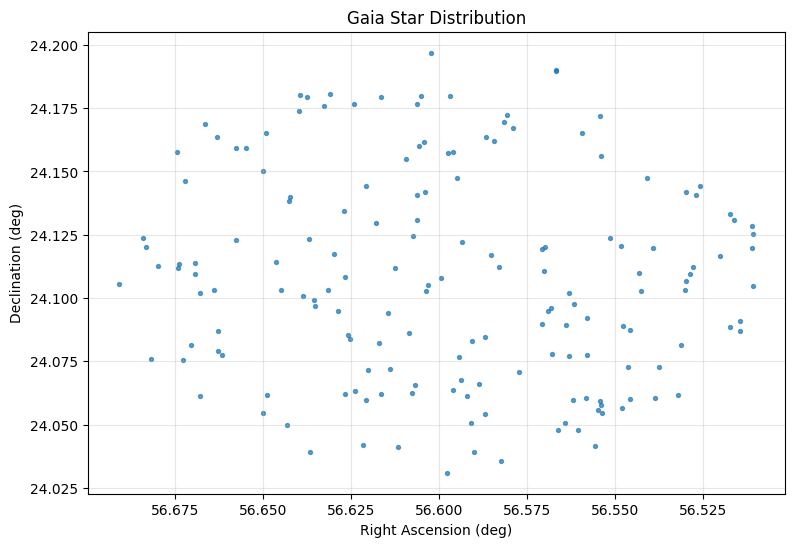

In [29]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    gaia_data["RAJ2000(deg)"],
    gaia_data["DEJ2000(deg)"],
    s=8,
    alpha=0.7
)

plt.xlabel("Right Ascension (deg)")
plt.ylabel("Declination (deg)")
plt.title("Gaia Star Distribution")

plt.gca().invert_xaxis()

plt.grid(alpha=0.3)
plt.show()

Estimate the mean and standard deviation of the Parallax (Plx), Proper Motion (PM), G magnitude (Gmag) and Colour Index (BP-RP)

In [30]:
mean_plx = gaia_data["Plx(mas)"].mean()
std_plx = gaia_data["Plx(mas)"].std()

print(f"Mean parallax = {mean_plx:.3f} mas, Standard deviation = {std_plx:.3f} mas")

mean_pm = gaia_data["PM(mas/yr)"].mean()
std_pm = gaia_data["PM(mas/yr)"].std()

print(f"Mean proper motion = {mean_pm:.3f} mas/yr, Standard deviation = {std_pm:.3f} mas/yr")

mean_Gmag = gaia_data["Gmag(mag)"].mean()
std_Gmag = gaia_data["Gmag(mag)"].std()

print(f"Mean G magnitude = {mean_Gmag:.3f} mag, Standard deviation = {std_Gmag:.3f} mag")

Mean parallax = 1.157 mas, Standard deviation = 1.894 mas
Mean proper motion = 10.770 mas/yr, Standard deviation = 16.534 mas/yr
Mean G magnitude = 18.368 mag, Standard deviation = 2.327 mag


Plot the Parallax as a histogram

Text(0.5, 1.0, 'Gaia DR3 Pleiades Parallax Distribution')

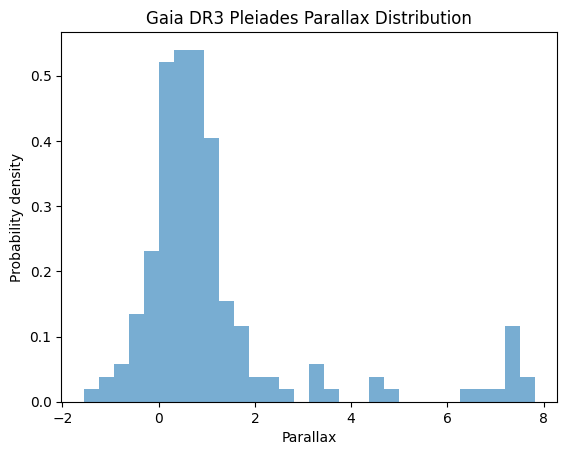

In [31]:
plt.hist(gaia_data["Plx(mas)"], bins=30, density=True, alpha=0.6)

plt.xlabel("Parallax")
plt.ylabel("Probability density")
plt.title("Gaia DR3 Pleiades Parallax Distribution")

Overlay a gaussian curve with the mean and standard deviation estimated previously. Plot the mean and 1 $\sigma$ of data-set.

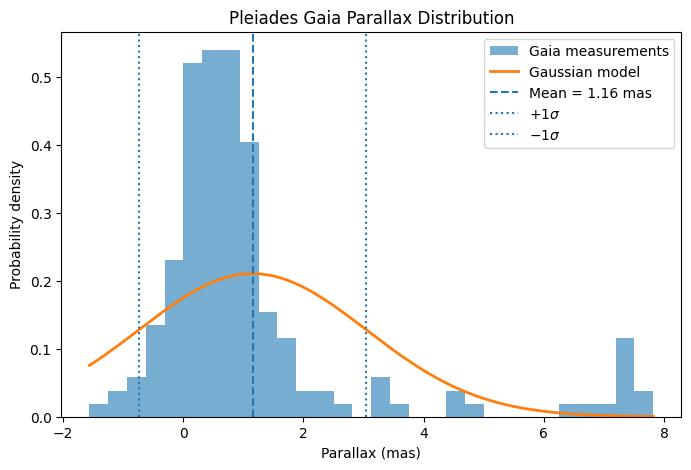

In [34]:

x = np.linspace(gaia_data["Plx(mas)"].min(), gaia_data["Plx(mas)"].max(), 500)

gaussian = norm.pdf(x, mean_plx, std_plx)

plt.figure(figsize=(8, 5))

plt.hist(gaia_data["Plx(mas)"], bins=30, density=True, alpha=0.6,
         label="Gaia measurements")

plt.plot(x, gaussian, linewidth=2,
         label="Gaussian model")

plt.axvline(mean_plx, linestyle="--",
            label=f"Mean = {mean_plx:.2f} mas")

plt.axvline(mean_plx + std_plx, linestyle=":",
            label=r"$+1\sigma$")

plt.axvline(mean_plx - std_plx, linestyle=":",
            label=r"$-1\sigma$")

plt.xlabel("Parallax (mas)")
plt.ylabel("Probability density")
plt.title("Pleiades Gaia Parallax Distribution")

plt.legend()
plt.show()

Calculate the z score of the data and plot them as histograms

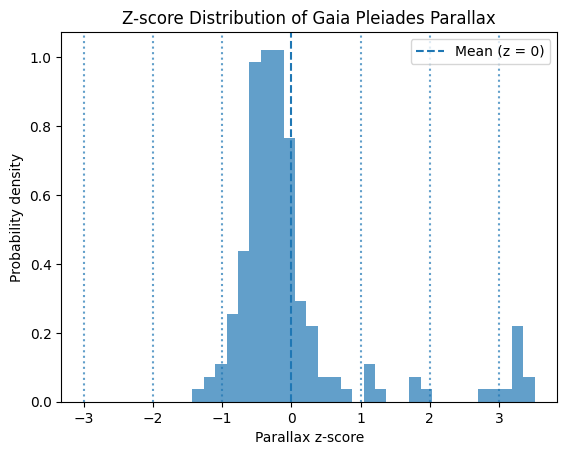

In [37]:
gaia_data["z_plx"] = (gaia_data["Plx(mas)"] - mean_plx) / std_plx

plt.hist(gaia_data["z_plx"], bins=30, density=True, alpha=0.7)

plt.xlabel("Parallax z-score")
plt.ylabel("Probability density")
plt.title("Z-score Distribution of Gaia Pleiades Parallax")

# Mark mean z-score = 0
plt.axvline(0, linestyle="--", label="Mean (z = 0)")

# Mark ±1, ±2 and ±3 sigma
for z in [-3, -2, -1, 1, 2, 3]:
    plt.axvline(z, linestyle=":", alpha=0.7)

plt.legend()
plt.show()

**Hypothesis testing** Assume the null hypothesis H$_{0}$: All stars in the Pleiades cluster have a mean parallax of 0.5 mas.
For the given sample of data-set, the parallax distribution of the data-set is equal to the parallax distribution of the Pleiades star cluster, H$_{0}$: $\mu$ = $\mu_{0}$

The alternative hypothesis is for the given data-set: H$_{a}$: $\mu \ne \mu_{0}$, which means the parallax distribution of the given data-set is different from that of the Pleiades star cluster.
This is a two-tailed test

For critical value approach to hypothesis testing, lets assume a significance $\alpha$ of 0.05. Calculate the t-statistic and p-value

In [51]:
t_stat, p_value = ttest_1samp(gaia_data["Plx(mas)"], mu0)

mu0 = 0.5

print(f"Mean parallax = {mean_plx:.3f} mas")
print(f"t-statistic = {t_stat:.3f}")
print(f"p-value = {p_value:.5f}")

Mean parallax = 1.157 mas
t-statistic = 4.469
p-value = 0.00001


The t-statistic tells us that the mean of the given data-set is 4.469$\sigma$ away from the true mean of the distribution and p value is very low. So it rejects the null hypothesis H$_{0}$ and selects the alternative hypothesis H$_{a}$ which says the parallax distribution of the stars in the sample is different from the parallax distribution of the stars in the Pleiades star cluster. You can plot it and check it visually.

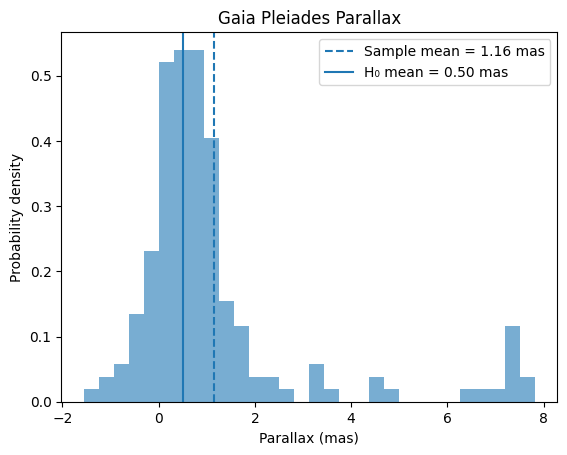

In [52]:
plt.hist(gaia_data["Plx(mas)"], bins=30, density=True, alpha=0.6)

plt.axvline(mean_plx, linestyle="--",
            label=f"Sample mean = {mean_plx:.2f} mas")

plt.axvline(mu0, linestyle="-",
            label=f"H₀ mean = {mu0:.2f} mas")

plt.xlabel("Parallax (mas)")
plt.ylabel("Probability density")
plt.title("Gaia Pleiades Parallax")
plt.legend()

plt.show()

**Type I error**: Reject H$_{0}$ when H$_{0}$ is actually true

**Type II error**: Accept H$_{0}$ when H$_{0}$ is actually false